## Transport in the Drygalski Basin 

### Goal:

- Estimate the transport of HSSW in the Drygalski Basin between mooring DITD and TNBD. What is the along trough transport of HSSW in the Drygalski Basin? How does this transport change seasonally? 

### Steps: 

- Rotate velocity into along and cross trough direction (will require figuring out the orientation of the Drygalski Trough)

- Make some assumptions about the width of HSSW current or trough and vertical extent of HSSW to use as area for multipying velocity by to get volume transport 

- Use salt and heat flux equations to get salt and heat transport 


### Data Needs: 

- TNBD 1100 m sensor velocity and CTD (need to average to same sampling frequency)

- DITD 1100 m sensor velocity and CTD (need to average to same sampling frequency)

- GEBCO bathymetry data 

- CTD data to help estimate what is the vertical extent of HSSW layer 


### Tasks to get started on: 

- load in TNBD and DITD data 

- Estimate the orientation of Drygalski Trough based on latitude and longitude of mooring data 

- Rotate currents to along and across trough 

- Make preliminary plots of along and across trough currents 

- Make some crude assumptions about width of HSSW current and vertical extent to estimate volume flow through the basin

In [11]:
# import packages 
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy import signal, interpolate

In [10]:
import numpy as np
import pandas as pd
from scipy import signal, interpolate

# ── 1. GEOMETRIC TROUGH ORIENTATION ─────────────────────────────────────────
def trough_orientation_from_moorings(lon1, lat1, lon2, lat2):
    """
    Estimate trough axis orientation from two mooring positions.
    
    Assumes the two along-trough moorings define the trough axis.
    Uses a local flat-Earth approximation (valid over short distances
    typical of continental shelf troughs, ~10s of km).
    
    Parameters
    ----------
    lon1, lat1 : float
        Position of mooring 1 (decimal degrees)
    lon2, lat2 : float
        Position of mooring 2 (decimal degrees)
    
    Returns
    -------
    theta_deg : float
        Angle of trough axis CCW from East (degrees)
        This is the angle you rotate velocities BY to get along-trough
    bearing_deg : float
        Geographic bearing from mooring 1 to mooring 2 (degrees CW from North)
        Useful for sanity-checking against a map
    dx, dy : float
        Approximate along-East and along-North separation (km)
    """
    # Mean latitude for scaling (flat-Earth approximation)
    lat_mean = np.deg2rad((lat1 + lat2) / 2.0)
    
    R_earth = 6371.0  # km
    
    # Zonal and meridional separation
    dx = R_earth * np.cos(lat_mean) * np.deg2rad(lon2 - lon1)  # km, East+
    dy = R_earth * np.deg2rad(lat2 - lat1)                      # km, North+
    
    # Angle CCW from East — this is theta for the rotation matrix
    theta_deg = np.rad2deg(np.arctan2(dy, dx))
    
    # Geographic bearing (CW from North) — easier to sanity-check on a map
    bearing_deg = np.rad2deg(np.arctan2(dx, dy)) % 360
    
    dist_km = np.sqrt(dx**2 + dy**2)
    
    print(f"Mooring separation:  {dist_km:.1f} km")
    print(f"dx (East):           {dx:.1f} km")
    print(f"dy (North):          {dy:.1f} km")
    print(f"Trough axis angle from East (theta): {theta_deg:.1f}°")
    print(f"Geographic bearing M1→M2:            {bearing_deg:.1f}° (CW from North)")
    print(f"\nSanity check: positive v_along will point toward M2")
    
    return theta_deg, bearing_deg, dx, dy


# ── 2. VELOCITY ROTATION ─────────────────────────────────────────────────────
def rotate_velocities(u, v, theta_deg):
    """
    Rotate (u=East, v=North) to (along-trough, across-trough).
    
    Sign convention: positive v_along points from mooring 1 toward mooring 2.
    Flip sign afterward if that's up-trough rather than toward shelf break.
    
    Parameters
    ----------
    u, v      : array-like, eastward and northward velocity (m/s)
    theta_deg : float, trough axis angle CCW from East
    
    Returns
    -------
    v_along, v_across : rotated velocity components (m/s)
    """
    theta = np.deg2rad(theta_deg)
    v_along  =  u * np.cos(theta) + v * np.sin(theta)
    v_across = -u * np.sin(theta) + v * np.cos(theta)
    return v_along, v_across


def principal_axis_angle(u, v):
    """
    Data-driven trough orientation from velocity variance ellipse.
    Use this to validate your geometric estimate — they should agree
    within ~10° for a well-channelized flow.
    """
    u_dm = u - np.nanmean(u)
    v_dm = v - np.nanmean(v)
    cov = np.cov(u_dm[~np.isnan(u_dm)], v_dm[~np.isnan(v_dm)])
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    major_axis = eigenvectors[:, np.argmax(eigenvalues)]
    theta_deg = np.rad2deg(np.arctan2(major_axis[1], major_axis[0]))
    return theta_deg


# ── 3. CROSS-SECTIONAL AREA ──────────────────────────────────────────────────
def estimate_cross_section(trough_widths_m, depth_bins_m, hssw_layer_top_m,
                            hssw_layer_bottom_m):
    """
    Estimate the cross-sectional area occupied by HSSW.
    
    For a single velocity measurement, this encodes your depth assumption.
    
    Parameters
    ----------
    trough_widths_m      : array of trough widths at each depth bin (m)
                           Get this from IBCSO/BedMachine bathymetry transect
    depth_bins_m         : array of depths corresponding to trough_widths_m (m)
    hssw_layer_top_m     : shallowest extent of HSSW layer (m, positive down)
                           Estimate from CTD casts or climatology
    hssw_layer_bottom_m  : deepest extent — usually trough floor at mooring loc
    
    Returns
    -------
    A_total    : total cross-sectional area of HSSW layer (m²)
    A_simple   : simple rectangular estimate W * H (m²) for comparison
    W_at_instr : trough width at instrument depth (m)
    """
    # Integrate trough width over the HSSW depth range
    mask = (depth_bins_m >= hssw_layer_top_m) & (depth_bins_m <= hssw_layer_bottom_m)
    
    if mask.sum() < 2:
        raise ValueError("Not enough depth bins within HSSW layer — "
                         "check your depth arrays")
    
    A_total = np.trapz(trough_widths_m[mask], depth_bins_m[mask])
    
    # Simple rectangular estimate (what you'd use with a single width value)
    H = hssw_layer_bottom_m - hssw_layer_top_m
    W_at_instr = float(np.interp(1100.0, depth_bins_m, trough_widths_m))
    A_simple = W_at_instr * H
    
    print(f"HSSW layer thickness:         {H:.0f} m")
    print(f"Trough width at 1100m:        {W_at_instr/1000:.1f} km")
    print(f"Area (integrated over width): {A_total/1e6:.2f} km²")
    print(f"Area (simple rectangle):      {A_simple/1e6:.2f} km²")
    print(f"Difference:                   {100*(A_total-A_simple)/A_simple:.1f}%")
    
    return A_total, A_simple, W_at_instr


def area_uncertainty(A_best, layer_thickness_uncertainty_m, W_at_instr):
    """
    Propagate layer thickness uncertainty into area and transport uncertainty.
    
    A rough ±1-sigma bound assuming your main uncertainty is in layer thickness.
    """
    A_low  = W_at_instr * (A_best / W_at_instr - layer_thickness_uncertainty_m)
    A_high = W_at_instr * (A_best / W_at_instr + layer_thickness_uncertainty_m)
    print(f"Area range: {A_low/1e6:.2f} – {A_high/1e6:.2f} km²")
    return A_low, A_high


# ── 4. FILTERING ─────────────────────────────────────────────────────────────
def lowpass_filter(data, cutoff_hours=36, dt_hours=1.0):
    """
    Zero-phase Butterworth low-pass filter.
    
    36h cutoff removes semidiurnal/diurnal tides and near-inertial motions.
    Inertial period at 70°S ~ 12.9h, so 36h is conservative.
    Consider 72h or 120h if you want to focus on synoptic/seasonal variability.
    """
    nyq = 0.5 / dt_hours          # Nyquist in cycles/hour
    fc  = 1.0 / cutoff_hours      # cutoff in cycles/hour
    b, a = signal.butter(4, fc / nyq, btype='low')
    # Handle NaNs by interpolating over gaps before filtering
    t = np.arange(len(data))
    finite = np.isfinite(data)
    data_filled = np.interp(t, t[finite], data[finite])
    filtered = signal.filtfilt(b, a, data_filled)
    filtered[~finite] = np.nan    # restore NaN gaps
    return filtered


# ── 5. HSSW IDENTIFICATION ───────────────────────────────────────────────────
def hssw_mask(salinity, temperature, S_threshold=34.6, T_threshold=-1.7):
    """
    Boolean mask for HSSW presence at the instrument.
    
    Adjust thresholds to your specific region — HSSW definitions vary
    between Ross Sea (~34.75), Weddell (~34.6), and other shelf troughs.
    Cross-reference against your CTD-based T/S diagram.
    """
    return (salinity >= S_threshold) & (temperature <= T_threshold)


# ── 6. TRANSPORT ─────────────────────────────────────────────────────────────
def compute_transports(v_along, salinity, temperature,
                       A, rho=1027.0, cp=3985.0, T_ref=-1.9):
    """
    Compute volume, salt, and heat transport time series.
    
    Parameters
    ----------
    v_along     : along-trough velocity (m/s), already low-pass filtered
    salinity    : practical salinity (g/kg)
    temperature : in-situ or potential temperature (°C)
    A           : cross-sectional area (m²)
    rho         : reference density (kg/m³) — ideally compute from T/S
    cp          : specific heat capacity (J/kg/K)
    T_ref       : reference temperature (°C) for heat transport
                  Use surface freezing point (~-1.9°C) for shelf work
    
    Returns
    -------
    dict of transport arrays, all as time series
    """
    Q   = v_along * A                              # m³/s
    F_S = rho * v_along * salinity * A             # kg/s
    F_H = rho * cp * v_along * (temperature - T_ref) * A  # W
    
    return {
        'Q_m3s':         Q,
        'Q_Sv':          Q / 1e6,
        'salt_flux_kgs': F_S,
        'heat_flux_W':   F_H,
        'heat_flux_GW':  F_H / 1e9,
    }


# ── 7. EDDY DECOMPOSITION ────────────────────────────────────────────────────
def eddy_flux_decomposition(v_along, scalar, A, rho=1027.0):
    """
    Decompose total flux into mean and eddy (turbulent) components.
    
    Total flux  = <v> * <S> * A  +  <v'S'> * A
    Mean flux   = v_bar * S_bar * A
    Eddy flux   = <v'S'> * A     (often non-negligible in troughs!)
    
    Works for salinity or temperature as the scalar.
    """
    v_bar = np.nanmean(v_along)
    s_bar = np.nanmean(scalar)
    
    v_prime = v_along - v_bar
    s_prime = scalar  - s_bar
    
    eddy_covariance = np.nanmean(v_prime * s_prime)
    
    mean_flux = rho * v_bar  * s_bar          * A
    eddy_flux = rho * eddy_covariance         * A
    total     = rho * np.nanmean(v_along * scalar) * A
    
    print(f"Mean flux:  {mean_flux:.2e}")
    print(f"Eddy flux:  {eddy_flux:.2e}  ({100*eddy_flux/total:.1f}% of total)")
    print(f"Total flux: {total:.2e}")
    
    return mean_flux, eddy_flux, total


# ── 8. MAIN WORKFLOW ─────────────────────────────────────────────────────────
def full_transport_pipeline(ds,
                             lon1, lat1, lon2, lat2,
                             trough_widths_m, depth_bins_m,
                             hssw_top_m, hssw_bottom_m,
                             S_thresh=34.6, T_thresh=-1.7,
                             T_ref=-1.9, dt_hours=1.0):
    """
    ds : xarray Dataset with variables u, v, temp, salinity (dim: time)
    lon1/lat1, lon2/lat2 : mooring positions (decimal degrees)
    trough_widths_m : trough width profile from bathymetry (m)
    depth_bins_m    : corresponding depths (m, positive down)
    hssw_top_m      : top of HSSW layer (m)
    hssw_bottom_m   : bottom of HSSW layer / trough floor (m)
    """
    # 1. Orientation
    print("=== TROUGH ORIENTATION ===")
    theta_geo, bearing, dx, dy = trough_orientation_from_moorings(
        lon1, lat1, lon2, lat2)
    theta_pca = principal_axis_angle(ds.u.values, ds.v.values)
    print(f"\nPCA angle cross-check: {theta_pca:.1f}°  "
          f"(difference: {abs(theta_geo - theta_pca):.1f}°)")
    print("If difference > 15°, examine whether flow is truly channelized\n")
    
    # Use geometric angle as primary; flag if PCA disagrees strongly
    theta = theta_geo
    
    # 2. Rotate
    v_along, v_across = rotate_velocities(ds.u.values, ds.v.values, theta)
    v_along_lp = lowpass_filter(v_along, cutoff_hours=36, dt_hours=dt_hours)
    
    # 3. Cross-sectional area
    print("=== CROSS-SECTIONAL AREA ===")
    A_integrated, A_simple, W_instr = estimate_cross_section(
        trough_widths_m, depth_bins_m, hssw_top_m, hssw_bottom_m)
    
    # 4. Transports (best estimate + uncertainty bounds)
    print("\n=== TRANSPORT (best estimate) ===")
    T_best = compute_transports(v_along_lp, ds.salinity.values,
                                 ds.temp.values, A_integrated)
    
    # 5. HSSW mask
    mask = hssw_mask(ds.salinity.values, ds.temp.values, S_thresh, T_thresh)
    print(f"\nHSSW present {100*mask.mean():.1f}% of record")
    
    # 6. Build output DataFrame
    df = pd.DataFrame({
        'v_along_raw':   v_along,
        'v_along_lp':    v_along_lp,
        'v_across':      v_across,
        'is_HSSW':       mask,
        **T_best
    }, index=ds.time.values)
    
    return df, theta_geo, A_integrated

In [58]:
# load in data 
# TNBD_ctd_bot = xr.open_dataset('//thepenguin/penguin2/Data/TNB/mooring/LDEO/TNBD_2018/working/tnbd_2018_ctd_bot_1093.nc')
# TNBD_vel_bot = xr.open_dataset('//thepenguin/penguin2/Data/TNB/mooring/LDEO/TNBD_2018/working/tnbd_2018_vel_bot_1093.nc')

DITD_ctd_top = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/DITD_2018_2019/DITD_2018_ctd_top.nc')
DITD_vel_top = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/DITD_2018_2019/vel_1100.nc')

In [59]:
# fix DITD time - should save this change permenantly later
DITD_vel_top['time'] = DITD_vel_top.time - pd.Timedelta(12,'h')

In [60]:
# rename variables in DITD velocity dataset 
DITD_vel_top = DITD_vel_top.rename({
    'east':'u',
    'north':'v',
    'up':'w',
    'pressure':'pres',
    'direction':'dir'
}).assign_coords({
    'z':1121,
    'lat':-75.28,
    'lon':164.1
})
# # rename variables in DITD velocity dataset 
# DITD_vel_bot = DITD_vel_bot.rename({
#     'east':'u',
#     'north':'v',
#     'up':'w',
#     'pressure':'pres',
#     'direction':'dir'
# }).assign_coords({
#     'z':1218,
#     'lat':-75.28,
#     'lon':164.1
# })

In [61]:
# convert velocity from m/s to cm/s 
# DITD_vel_top['u'] = DITD_vel_top.u * 100
# DITD_vel_top['v'] = DITD_vel_top.v * 100
# DITD_vel_top['speed'] = DITD_vel_top.speed * 100

# DITD_vel_bot['v'] = DITD_vel_bot.v * 100
# DITD_vel_bot['u'] = DITD_vel_bot.u * 100
# DITD_vel_bot['speed'] = DITD_vel_bot.speed * 100


In [62]:
tnbd_lat = -75.0112
tnbd_lon = 165.5562

ditd_lat = -75.2751
ditd_lon = 164.0625

In [63]:
theta_deg, bearing_deg, dx, dy = trough_orientation_from_moorings(lon1=ditd_lon, lat1=ditd_lat, lon2=tnbd_lon, lat2=tnbd_lat)

Mooring separation:  51.7 km
dx (East):           42.6 km
dy (North):          29.3 km
Trough axis angle from East (theta): 34.6°
Geographic bearing M1→M2:            55.4° (CW from North)

Sanity check: positive v_along will point toward M2


In [64]:
principal_axis_angle(DITD_vel_top.u, DITD_vel_top.v)

np.float64(-126.06119018649993)

In [65]:
v_along, v_across = rotate_velocities(DITD_vel_top.u, DITD_vel_top.v, theta_deg)

In [66]:
v_along

<xarray.DataArray (time: 42912)> Size: 343kB
array([0.02268919, 0.03333011, 0.02985068, ..., 0.01430294, 0.01143144,
       0.00074488], shape=(42912,))
Coordinates:
  * time     (time) datetime64[ns] 343kB 2018-03-10T12:00:00 ... 2019-01-02T1...
    index    (time) int64 343kB 480 481 482 483 484 ... 43388 43389 43390 43391
    z        int64 8B 1121
    lat      float64 8B -75.28
    lon      float64 8B 164.1

In [67]:
v_across

<xarray.DataArray (time: 42912)> Size: 343kB
array([-0.02170716, -0.00583987, -0.00943063, ...,  0.04378842,
        0.05548263,  0.03353275], shape=(42912,))
Coordinates:
  * time     (time) datetime64[ns] 343kB 2018-03-10T12:00:00 ... 2019-01-02T1...
    index    (time) int64 343kB 480 481 482 483 484 ... 43388 43389 43390 43391
    z        int64 8B 1121
    lat      float64 8B -75.28
    lon      float64 8B 164.1

In [68]:
DITD_ctd_resampled = DITD_ctd_top.resample(time='10min').mean()

In [69]:
DITD_ctd = DITD_ctd_resampled.sel(time=DITD_vel_top.time)

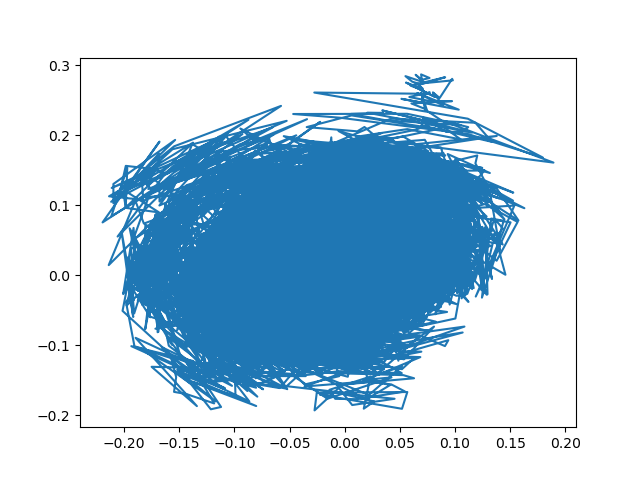

In [70]:
fig = plt.figure()
plt.plot(DITD_vel_top.u,DITD_vel_top.v)

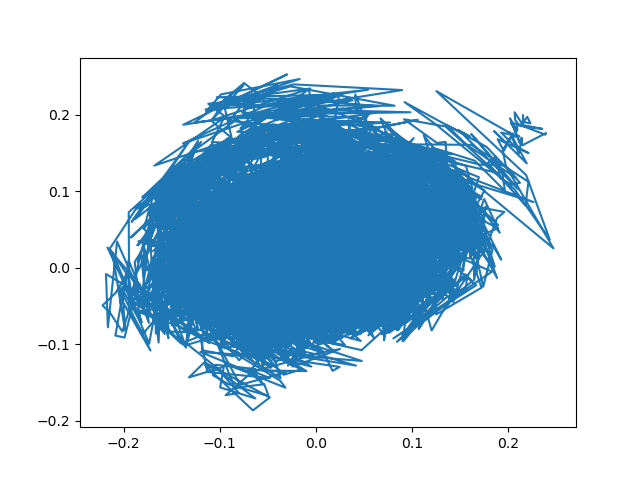

In [71]:
fig = plt.figure()
plt.plot(v_along,v_across)

In [72]:
def compute_transports(v_along, salinity, temperature,
                       A, rho=1027.0, cp=3985.0, T_ref=-1.9):
    """
    Compute volume, salt, and heat transport time series.
    
    Parameters
    ----------
    v_along     : along-trough velocity (m/s), already low-pass filtered
    salinity    : practical salinity (g/kg)
    temperature : in-situ or potential temperature (°C)
    A           : cross-sectional area (m²)
    rho         : reference density (kg/m³) — ideally compute from T/S
    cp          : specific heat capacity (J/kg/K)
    T_ref       : reference temperature (°C) for heat transport
                  Use surface freezing point (~-1.9°C) for shelf work
    
    Returns
    -------
    dict of transport arrays, all as time series
    """
    Q   = v_along * A                              # m³/s
    F_S = rho * v_along * salinity * A             # kg/s
    F_H = rho * cp * v_along * (temperature - T_ref) * A  # W
    
    return {
        'Q_m3s':         Q,
        'Q_Sv':          Q / 1e6,
        'salt_flux_kgs': F_S,
        'heat_flux_W':   F_H,
        'heat_flux_GW':  F_H / 1e9,
    }

In [73]:
v_along

<xarray.DataArray (time: 42912)> Size: 343kB
array([0.02268919, 0.03333011, 0.02985068, ..., 0.01430294, 0.01143144,
       0.00074488], shape=(42912,))
Coordinates:
  * time     (time) datetime64[ns] 343kB 2018-03-10T12:00:00 ... 2019-01-02T1...
    index    (time) int64 343kB 480 481 482 483 484 ... 43388 43389 43390 43391
    z        int64 8B 1121
    lat      float64 8B -75.28
    lon      float64 8B 164.1

In [74]:
sal = DITD_ctd.abs_sal

In [75]:
sal

<xarray.DataArray 'abs_sal' (time: 42912)> Size: 343kB
array([35.02278445, 35.02285133, 35.02286203, ..., 35.01338291,
       35.01346214, 35.0134005 ], shape=(42912,))
Coordinates:
  * time     (time) datetime64[ns] 343kB 2018-03-10T12:00:00 ... 2019-01-02T1...
    lat      float64 8B -75.28
    lon      float64 8B 164.1
    z        int64 8B 1121
    index    (time) int64 343kB ...

In [76]:
theta = DITD_ctd.theta

In [77]:
DITD_ctd

<xarray.Dataset> Size: 3MB
Dimensions:    (time: 42912)
Coordinates:
  * time       (time) datetime64[ns] 343kB 2018-03-10T12:00:00 ... 2019-01-02...
    lat        float64 8B -75.28
    lon        float64 8B 164.1
    z          int64 8B 1121
    index      (time) int64 343kB ...
Data variables:
    temp       (time) float64 343kB -1.89 -1.89 -1.89 ... -1.891 -1.891 -1.891
    con        (time) float64 343kB 2.782 2.782 2.782 ... 2.782 2.782 2.782
    pres       (time) float64 343kB 1.122e+03 1.122e+03 ... 1.122e+03 1.122e+03
    abs_sal    (time) float64 343kB 35.02 35.02 35.02 ... 35.01 35.01 35.01
    cons_temp  (time) float64 343kB -1.919 -1.919 -1.919 ... -1.921 -1.921
    sigma0     (time) float64 343kB 1.028e+03 1.028e+03 ... 1.028e+03 1.028e+03
    theta      (time) float64 343kB -1.922 -1.922 -1.922 ... -1.923 -1.924
    sal        (time) float64 343kB 34.85 34.85 34.85 ... 34.84 34.84 34.84

In [78]:
width = 10000 #m
vertical_extent = 100 #m 

In [79]:
A = width * vertical_extent 

In [80]:
A

1000000

In [81]:
rho = DITD_ctd.sigma0

In [82]:
F_S = rho * v_along * sal * A

In [83]:
F_S_cross = rho * v_across * sal * A

In [84]:
F_S

<xarray.DataArray (time: 42912)> Size: 343kB
array([8.16945141e+08, 1.20008346e+09, 1.07480366e+09, ...,
       5.14848498e+08, 4.11486983e+08, 2.68125298e+07], shape=(42912,))
Coordinates:
  * time     (time) datetime64[ns] 343kB 2018-03-10T12:00:00 ... 2019-01-02T1...
    lat      float64 8B -75.28
    lon      float64 8B 164.1
    z        int64 8B 1121
    index    (time) int64 343kB 480 481 482 483 484 ... 43388 43389 43390 43391

In [85]:
%matplotlib widget

Text(0, 0.5, 'Salt Transport (g/sec)')

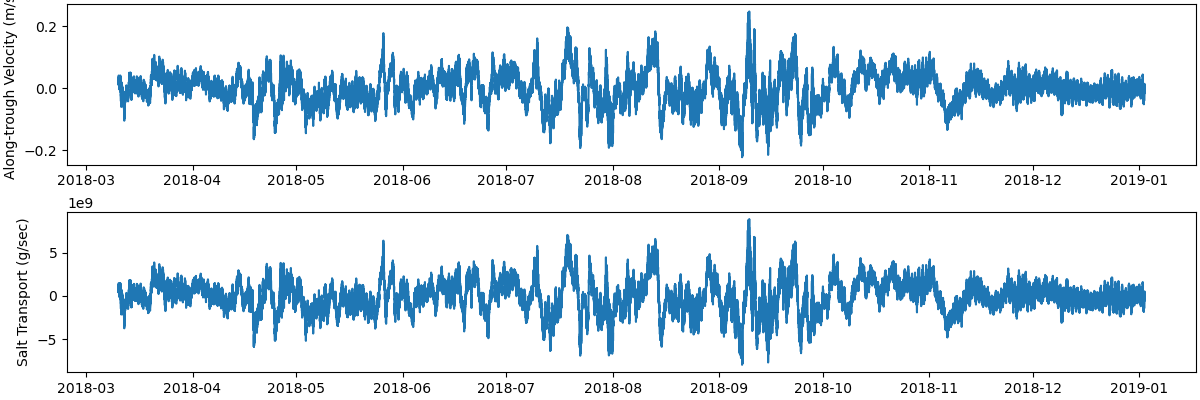

In [86]:
fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(12,4), constrained_layout=True)

ax[0].plot(v_along.time,v_along)
ax[0].set_ylabel('Along-trough Velocity (m/s)')

ax[1].plot(F_S.time,F_S)
ax[1].set_ylabel('Salt Transport (g/sec)')

In [87]:
import numpy as np
import pandas as pd
from scipy import stats, signal
import matplotlib.pyplot as plt

def salinity_anomaly(salinity, window_days=30, dt_hours=1.0):
    """Remove running mean to get salinity anomaly."""
    window_pts = int(window_days * 24 / dt_hours)
    S_mean = pd.Series(salinity).rolling(window_pts, center=True,
                                          min_periods=window_pts//2).mean().values
    S_mean = np.where(np.isnan(S_mean), np.nanmean(salinity), S_mean)
    return salinity - S_mean


def xcorr_sal_vel(time, salinity, v_along, max_lag_days=30, dt_hours=1.0):
    """
    Cross-correlate salinity anomaly with along-trough velocity.
    Positive lag = velocity lags salinity.
    """
    # Salinity anomaly
    S_anom = salinity_anomaly(salinity)

    # Drop NaNs
    valid  = np.isfinite(S_anom) & np.isfinite(v_along)
    S      = (S_anom[valid] - np.mean(S_anom[valid])) / np.std(S_anom[valid])
    V      = (v_along[valid] - np.mean(v_along[valid])) / np.std(v_along[valid])

    # Cross-correlation
    max_lag_pts = int(max_lag_days * 24 / dt_hours)
    lags_pts    = np.arange(-max_lag_pts, max_lag_pts + 1)
    lags_days   = lags_pts * dt_hours / 24.0
    corr        = np.array([
        np.corrcoef(S[:len(S)+lag], V[-lag:])[0,1] if lag < 0 else
        np.corrcoef(S[lag:],        V[:len(V)-lag])[0,1] if lag > 0 else
        np.corrcoef(S, V)[0,1]
        for lag in lags_pts
    ])

    # Significance threshold (accounts for autocorrelation)
    ac_S  = [np.corrcoef(S[:-k], S[k:])[0,1] for k in range(1, min(200, len(S)//2))]
    ac_V  = [np.corrcoef(V[:-k], V[k:])[0,1] for k in range(1, min(200, len(V)//2))]
    n_eff = len(S) / (1 + 2 * np.sum(np.array(ac_S) * np.array(ac_V)))
    n_eff = np.clip(n_eff, 4, len(S))
    t_crit = stats.t.ppf(0.975, df=n_eff - 2)
    r_crit = t_crit / np.sqrt(n_eff - 2 + t_crit**2)

    peak_idx  = np.argmax(np.abs(corr))
    peak_lag  = lags_days[peak_idx]
    peak_corr = corr[peak_idx]

    print(f"Peak correlation:  r = {peak_corr:.3f} at lag {peak_lag:+.1f} days")
    print(f"95% significance threshold: r = ±{r_crit:.3f}")
    print(f"Effective sample size: {n_eff:.0f}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

    # Panel A: time series
    ax1b = ax1.twinx()
    ax1.plot(time[valid],  S_anom[valid], color='#0F6E56', lw=0.9,
             alpha=0.8, label="S' (psu)")
    ax1b.plot(time[valid], v_along[valid], color='#534AB7', lw=0.9,
              alpha=0.7, label='v along-trough (m/s)')
    ax1.axhline(0, color='#0F6E56', lw=0.5, ls='--', alpha=0.4)
    ax1b.axhline(0, color='#534AB7', lw=0.5, ls='--', alpha=0.4)
    ax1.set_ylabel("S' (psu)",       color='#0F6E56')
    ax1b.set_ylabel("v along (m/s)", color='#534AB7')
    ax1.tick_params(axis='y', colors='#0F6E56')
    ax1b.tick_params(axis='y', colors='#534AB7')
    lines = ax1.get_lines() + ax1b.get_lines()
    ax1.legend(lines, [l.get_label() for l in lines], fontsize=9, loc='upper right')
    ax1.set_title("Salinity anomaly and along-trough velocity", fontsize=11)
    ax1.tick_params(axis='x', rotation=20)

    # Panel B: cross-correlation
    ax2.axhspan(-r_crit, r_crit, color='gray', alpha=0.12,
                label=f'95% significance (±{r_crit:.2f})')
    ax2.plot(lags_days, corr, color='#534AB7', lw=2)
    ax2.axvline(peak_lag, color='#D85A30', ls='--', lw=1.5,
                label=f'Peak: r={peak_corr:.2f} at {peak_lag:+.1f} d')
    ax2.axvline(0, color='k', lw=0.7, ls=':')
    ax2.axhline(0, color='k', lw=0.5)
    ax2.set_xlabel("Lag (days)  [+ = velocity lags salinity]")
    ax2.set_ylabel("Correlation")
    ax2.set_ylim(-1, 1)
    ax2.set_title("Cross-correlation: S' vs along-trough velocity", fontsize=11)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('xcorr.png', dpi=150, bbox_inches='tight')

    return lags_days, corr, peak_lag, peak_corr, r_crit


# ── Usage ─────────────────────────────────────────────────────────────────────
# lags, corr, peak_lag, peak_corr, r_crit = xcorr_sal_vel(
#     time     = ds.time.values,
#     salinity = ds.salinity.values,
#     v_along  = v_along_lowpassed,
#     max_lag_days = 30,
#     dt_hours     = 1.0
# )

Peak correlation:  r = -0.110 at lag -3.3 days
95% significance threshold: r = ±0.083
Effective sample size: 554


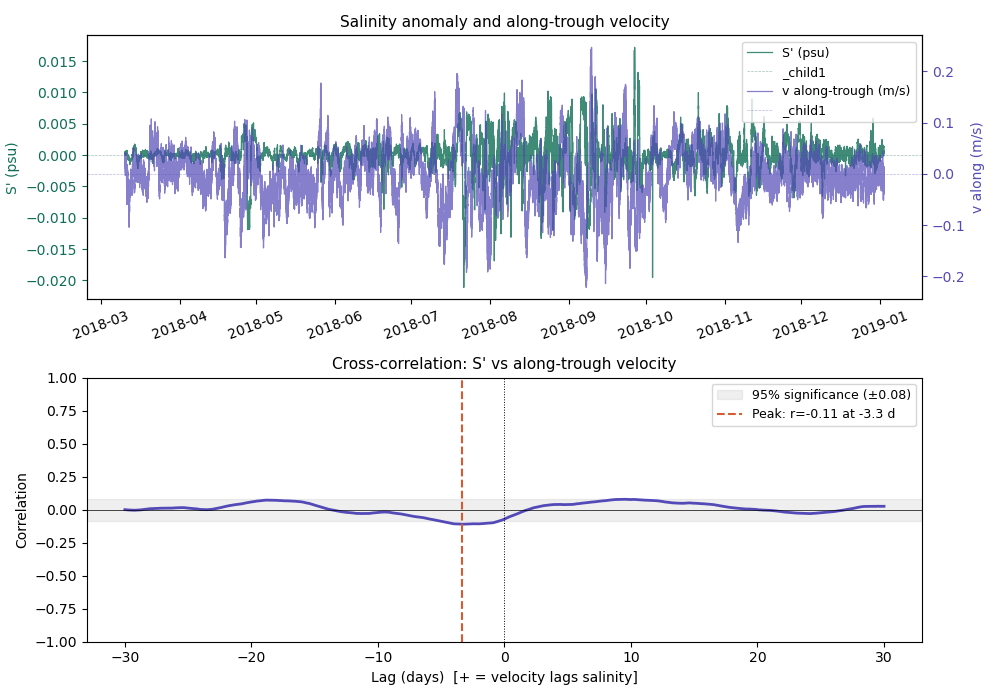

In [88]:
#── Usage ─────────────────────────────────────────────────────────────────────
lags, corr, peak_lag, peak_corr, r_crit = xcorr_sal_vel(
    time     = DITD_ctd.time.values,
    salinity = sal.values,
    v_along  = v_along,
    max_lag_days = 30,
    dt_hours     = 1.0
)

In [89]:
sal.mean()

<xarray.DataArray 'abs_sal' ()> Size: 8B
array(35.01185679)
Coordinates:
    lat      float64 8B -75.28
    lon      float64 8B 164.1
    z        int64 8B 1121

In [90]:
sal_anom = sal - sal.mean()

C:\Users\mblan\AppData\Local\Temp\ipykernel_23468\1709790807.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12,4))


(-0.3, 0.3)

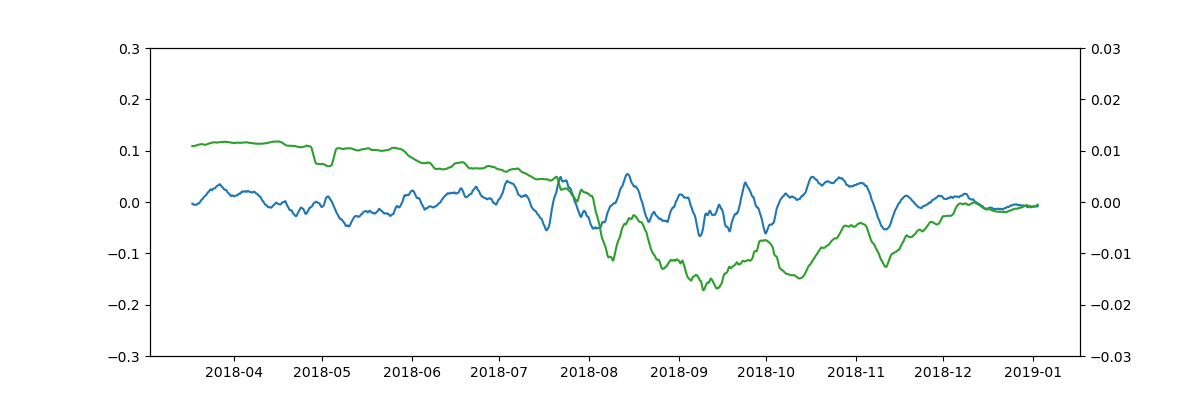

In [99]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(v_along.rolling(time=1008).mean().time,v_along.rolling(time=1008).mean())
twinx = ax.twinx()
twinx.plot(sal_anom.rolling(time=1008).mean().time,sal_anom.rolling(time=1008).mean(),color='tab:green')
twinx.set_ylim(-0.03,0.03)
ax.set_ylim(-0.3,0.3)

In [100]:
plt.close('all')